> **STATUS — 100% SYNTHETIC.**
>
> Every operator, response, and comparison in this notebook is built from a
> known ground-truth `J`. The four "inferred methods" (`exact`,
> `grn_like_noisy_edges`, `symmetric_only`, `diagonal_only`) are
> constructed by perturbing or projecting the ground truth — they are not
> outputs of any real inference tool. Nothing here uses real single-cell
> data. Use this notebook to verify the tool's algorithms and to see what
> the figures look like when the assumptions hold; do not cite any number
> or figure as a biological result.
>
> **Additional caveat.** The synthetic data here is *generated* under the
> additive-input model, so the tool recovers it exactly by construction.
> This does not validate that anchor-op recovers real CRISPRi biology,
> which is closer to intervention — see `SPEC.md` §Modeling assumption
> caveat and the intervention experiment in
> `scratchpad/intervention_vs_additive.py`.

# 04 — Synthetic walkthrough with figures

An end-to-end demonstration of `anchor-op` on a synthetic ground-truth
Jacobian. Because the true `J` is known, every claim in the notebook can be
checked against it. Real Perturb-seq datasets are used through the same
`measure_from_sensitivity` / `measure_operator` APIs; the K562/RPE1 protocols
live in the sibling notebooks and are deliberately not executed here.

The notebook exercises:

1. Constructing a `J` with oscillatory pairs and one hyperbolic real mode.
2. Simulating guide-level sensitivity `S` and perturbation input `U` matrices.
3. Calling `measure_from_sensitivity` with the preregistered `rank_tol=1e-2`.
4. Inspecting the `AnchorReport` and the singular-spectrum cutoff.
5. Visualizing operator and eigenvalue recovery.
6. Benchmarking four synthetic "inferred" operators against declared nulls,
   including the projected symmetric/antisymmetric split.
7. Demonstrating the `rank_tol` fix on noise-hidden guide collinearity.

## 1. Imports and ground-truth Jacobian

Constructed from real Schur blocks: two damped oscillatory 2×2 blocks (complex
eigenvalue pairs — real biological Jacobians have these whenever regulation is
directional), one strongly damped real mode, and one weakly hyperbolic real
mode. The oscillatory blocks give the operator a genuine antisymmetric part,
which is what the preregistered sym/antisym prediction is about.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import anchorop as ao


def build_ground_truth(d: int = 6, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    schur = np.array(
        [
            [-1.0, 1.5, 0.0, 0.0, 0.0, 0.0],
            [-1.5, -1.0, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, -0.7, 0.9, 0.0, 0.0],
            [0.0, 0.0, -0.9, -0.7, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, -1.8, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 0.12],
        ]
    )
    V = np.eye(d) + 0.25 * rng.normal(size=(d, d))
    return V @ schur @ np.linalg.inv(V)


J_true = build_ground_truth()
d = J_true.shape[0]
print("Ground-truth eigenvalues (real parts):", np.sort(np.linalg.eigvals(J_true).real).round(3))

Ground-truth eigenvalues (real parts): [-1.8  -1.   -1.   -0.7  -0.7   0.12]


## 2. Simulate guide-level `S` and `U`

We simulate at the S/U level rather than at the AnnData level so the linear
response model `J S = -U` holds exactly modulo measurement noise. The full
AnnData path (`fit_programs` → `measure_operator`) is exercised by the test
suite; the algebra is the same, just wrapped in the guide-matching and
target-encoding pipeline.

In [2]:
def simulate_S_and_U(
    J: np.ndarray,
    *,
    n_guides_per_gene: int = 3,
    kd_efficiency: float = 0.7,
    noise: float = 0.02,
    seed: int = 1,
) -> tuple[np.ndarray, np.ndarray, list[str], dict[str, float]]:
    rng = np.random.default_rng(seed)
    d = J.shape[0]
    guide_names: list[str] = []
    efficiencies: dict[str, float] = {}
    U_cols: list[np.ndarray] = []
    for gene_index in range(d):
        for k in range(n_guides_per_gene):
            eff = float(np.clip(kd_efficiency + 0.1 * rng.normal(), 0.2, 0.95))
            name = f"guide_g{gene_index}_{k}"
            guide_names.append(name)
            efficiencies[name] = eff
            U_cols.append(-eff * np.eye(d)[gene_index])
    U = np.column_stack(U_cols)
    S_clean = -np.linalg.solve(J, U)
    S = S_clean + noise * rng.normal(size=S_clean.shape)
    return S, U, guide_names, efficiencies


S, U, guide_names, efficiencies = simulate_S_and_U(J_true)
print(f"Simulated S: {S.shape} (d={d} programs x {S.shape[1]} guides)")

Simulated S: (6, 18) (d=6 programs x 18 guides)


## 3. Measure the operator

`rank_tol=1e-2` is the preregistered scientific default: a singular direction
of `S` must exceed 1% of `σ_max` to be treated as identified. `bootstrap=64`
resamples guide columns to get an operator covariance estimate.

In [3]:
measurement = ao.measure_from_sensitivity(
    S,
    U,
    guide_names=guide_names,
    guide_efficiencies=efficiencies,
    reg="tsvd",
    reg_param="path",
    rank_tol=1e-2,
    bootstrap=64,
    bootstrap_seed=7,
)
r = measurement.report
print("full_domain_identified :", r.full_domain_identified)
print("effective_response_rank:", r.effective_response_rank, "/", r.d)
print("condition_number       :", round(r.condition_number, 2))
print("retained guides        :", len(r.retained_guides))
print("rank_tol used          :", r.rank_tol)

full_domain_identified : True
effective_response_rank: 6 / 6
condition_number       : 21.31
retained guides        : 18
rank_tol used          : 0.01


## 4. Singular spectrum with the `rank_tol` cutoff

The cutoff line makes explicit which directions were counted toward the
identified subspace and which were treated as noise. Here every direction
survives — the measurement is full rank.

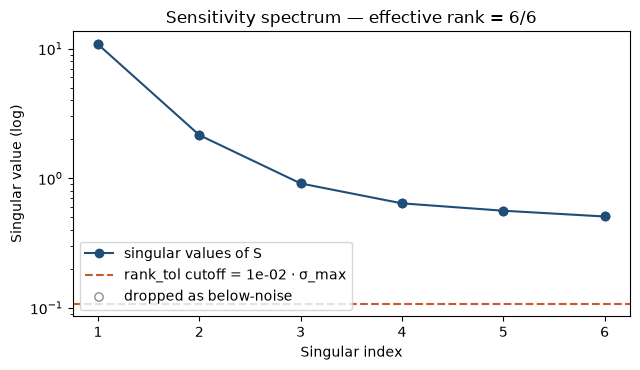

In [4]:
def plot_singular_spectrum(measurement, title_suffix=""):
    r = measurement.report
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ranks = np.arange(1, r.singular_values.size + 1)
    ax.semilogy(ranks, r.singular_values, "o-", color="#1f4e79", label="singular values of S")
    if r.rank_tol is not None:
        cutoff = r.rank_tol * float(r.singular_values[0])
        ax.axhline(cutoff, ls="--", color="#c65a30", label=f"rank_tol cutoff = {r.rank_tol:.0e} · σ_max")
    kept = r.retained_singular_directions
    ax.scatter(ranks[kept], r.singular_values[kept], color="#1f4e79", zorder=3)
    ax.scatter(ranks[~kept], r.singular_values[~kept], facecolors="none",
               edgecolors="#8f8f8f", label="dropped as below-noise", zorder=3)
    ax.set_xlabel("Singular index")
    ax.set_ylabel("Singular value (log)")
    ax.set_title(f"Sensitivity spectrum — effective rank = {r.effective_response_rank}/{r.d}{title_suffix}")
    ax.legend(loc="lower left")
    fig.tight_layout()
    return fig


plot_singular_spectrum(measurement);

## 5. Measured vs ground-truth operator

Side-by-side heatmaps of `J_true`, `J_measured`, and the residual. Note the
residual color scale is 5× tighter than the operator scale.

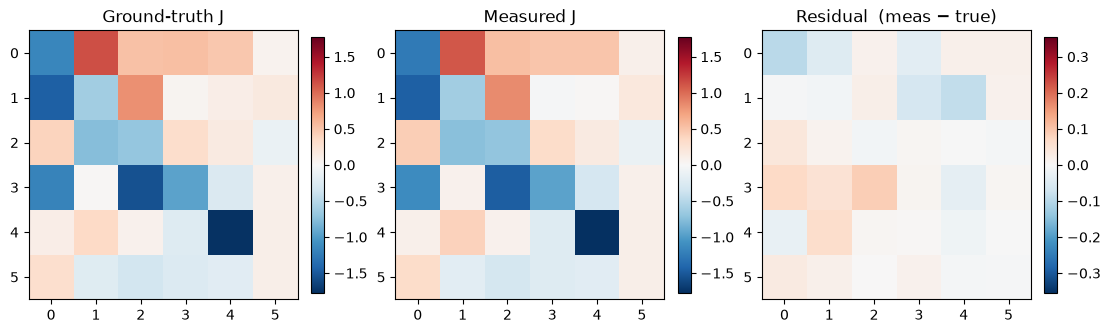

In [5]:
def plot_recovery(J_true, measurement):
    J_measured = measurement.J
    residual = J_measured - J_true
    vmax = float(np.max(np.abs([J_true, J_measured])))
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), constrained_layout=True)
    for ax, matrix, title, cbar_max in zip(
        axes,
        [J_true, J_measured, residual],
        ["Ground-truth J", "Measured J", "Residual  (meas − true)"],
        [vmax, vmax, vmax * 0.2],
    ):
        im = ax.imshow(matrix, vmin=-cbar_max, vmax=cbar_max, cmap="RdBu_r")
        ax.set_title(title)
        ax.set_xticks(range(matrix.shape[0]))
        ax.set_yticks(range(matrix.shape[0]))
        fig.colorbar(im, ax=ax, shrink=0.75)
    return fig


plot_recovery(J_true, measurement);

## 6. Eigenvalue recovery in the complex plane

Both the oscillatory pairs (complex conjugate eigenvalues, giving the operator
its antisymmetric structure) and the weakly hyperbolic real mode (Re λ ≈ 0.12)
are recovered.

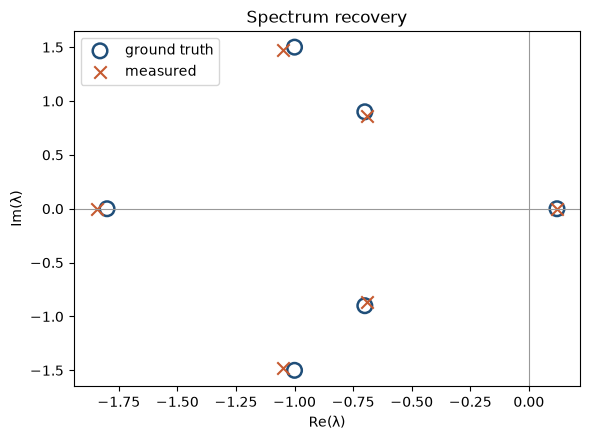

In [6]:
def plot_eigenvalues(J_true, measurement):
    e_true = np.linalg.eigvals(J_true)
    e_meas = np.linalg.eigvals(measurement.J)
    fig, ax = plt.subplots(figsize=(6.0, 4.5))
    ax.axvline(0.0, color="#999", lw=0.8)
    ax.axhline(0.0, color="#999", lw=0.8)
    ax.scatter(e_true.real, e_true.imag, marker="o", s=110, facecolors="none",
               edgecolors="#1f4e79", linewidths=1.8, label="ground truth")
    ax.scatter(e_meas.real, e_meas.imag, marker="x", s=80, color="#c65a30", label="measured")
    ax.set_xlabel("Re(λ)")
    ax.set_ylabel("Im(λ)")
    ax.set_title("Spectrum recovery")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return fig


plot_eigenvalues(J_true, measurement);

## 7. Benchmark four synthetic "inferred" operators

Four stand-ins span the plausible quality range:

- `exact` — an oracle upper bound.
- `grn_like_noisy_edges` — right topology, noisy weights.
- `symmetric_only` — a method that recovers only the symmetric part
  (e.g., a diffusion-flavored drift model that discards directional regulation).
- `diagonal_only` — a method that recovers only self-regulation.

In [7]:
def synthesize_inferred_methods(J_true, seed=42):
    rng = np.random.default_rng(seed)
    return {
        "exact": J_true.copy(),
        "grn_like_noisy_edges": J_true + 0.15 * rng.normal(size=J_true.shape),
        "symmetric_only": 0.5 * (J_true + J_true.T),
        "diagonal_only": np.diag(np.diag(J_true)),
    }


methods = synthesize_inferred_methods(J_true)
results = ao.compare(
    measurement,
    methods,
    nulls=("shuffled_edges", "random_init"),
    n_null=100,
    seed=11,
)
table = ao.comparison_table(results)
table[[
    "method",
    "operator_relative_error",
    "spectral_abscissa_difference",
    "symmetric_relative_error",
    "antisymmetric_relative_error",
    "shuffled_edges:operator_relative_error:mean",
    "random_init:operator_relative_error:mean",
]].round(3)

,method,operator_relative_error,spectral_abscissa_difference,symmetric_relative_error,antisymmetric_relative_error,shuffled_edges:operator_relative_error:mean,random_init:operator_relative_error:mean
0,exact,0.055,0.000,0.049,0.061,1.385,1.420
1,grn_like_noisy_edges,0.195,0.112,0.195,0.196,1.348,1.404
2,symmetric_only,0.692,0.062,0.049,1.000,1.178,1.215
3,diagonal_only,0.776,0.016,0.486,1.000,1.135,1.164


## 8. Method error vs null distributions

Left: projected operator relative error, with the two null means overlaid.
Right: spectral abscissa difference — the direct hyperbolicity-magnitude
comparison, robust to the non-normal instability that afflicts the full
eigenvalue Wasserstein metric.

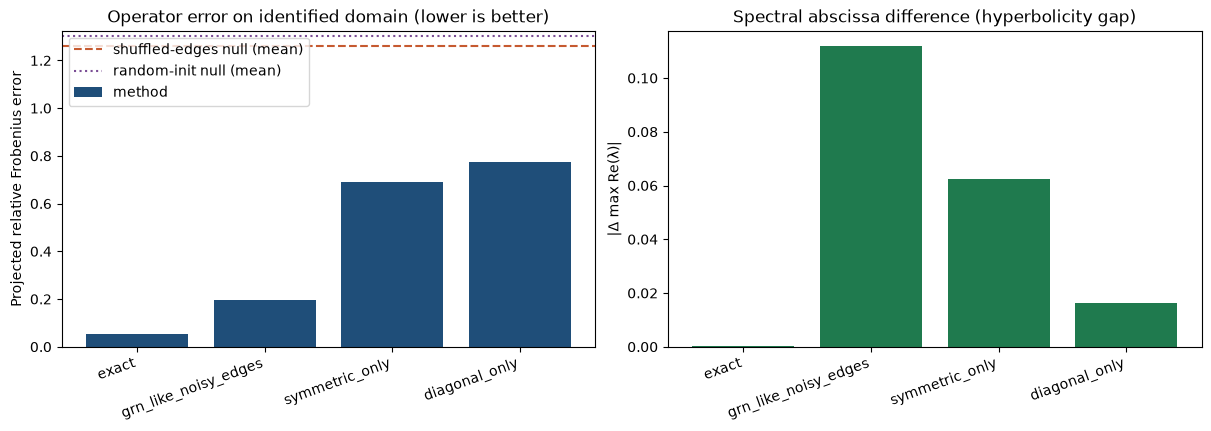

In [8]:
def plot_benchmark(results):
    method_names = list(results)
    ops = np.array([results[m].metrics["operator_relative_error"] for m in method_names])
    abscissae = np.array([results[m].metrics["spectral_abscissa_difference"] for m in method_names])
    null_op = np.concatenate([
        results[m].null_metrics.get("shuffled_edges:operator_relative_error", np.array([]))
        for m in method_names
    ])
    null_random = np.concatenate([
        results[m].null_metrics.get("random_init:operator_relative_error", np.array([]))
        for m in method_names
    ])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
    x = np.arange(len(method_names))
    ax1.bar(x, ops, color="#1f4e79", label="method")
    ax1.axhline(np.mean(null_op), color="#c65a30", ls="--", label="shuffled-edges null (mean)")
    ax1.axhline(np.mean(null_random), color="#7a4d95", ls=":", label="random-init null (mean)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(method_names, rotation=20, ha="right")
    ax1.set_ylabel("Projected relative Frobenius error")
    ax1.set_title("Operator error on identified domain (lower is better)")
    ax1.legend(loc="upper left")
    ax2.bar(x, abscissae, color="#1f7a4e")
    ax2.set_xticks(x)
    ax2.set_xticklabels(method_names, rotation=20, ha="right")
    ax2.set_ylabel("|Δ max Re(λ)|")
    ax2.set_title("Spectral abscissa difference (hyperbolicity gap)")
    return fig


plot_benchmark(results);

## 9. Symmetric vs antisymmetric errors — the preregistered prediction

The preregistered prediction (see `PREREGISTRATION.md`) is that inferred
methods will recover the projected symmetric component better than the
antisymmetric component. On this synthetic setup where the ground truth has
genuine oscillatory (antisymmetric) structure:

- `exact` recovers both to noise level.
- `symmetric_only` scores 0 on sym error and 1.0 (fully missed) on antisym.
- `diagonal_only` misses both off-diagonal parts.
- `grn_like_noisy_edges` scores intermediate on both.

Real benchmark data will decide whether this preregistered directional
prediction holds across methods.

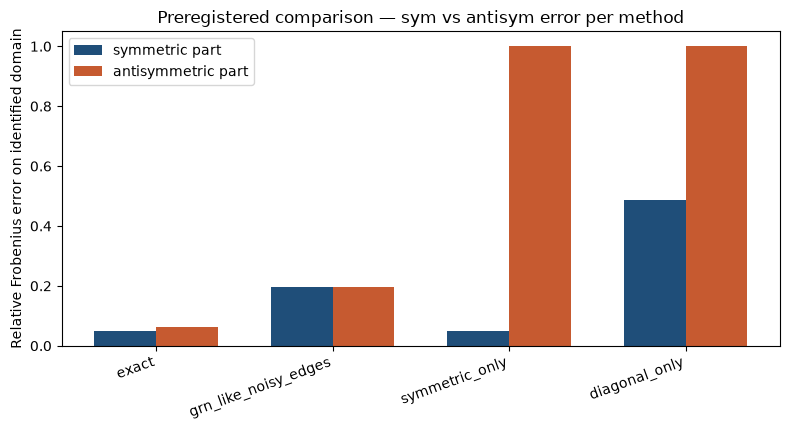

In [9]:
def plot_sym_antisym(results):
    method_names = list(results)
    sym = np.array([results[m].metrics["symmetric_relative_error"] for m in method_names])
    antisym = np.array([results[m].metrics["antisymmetric_relative_error"] for m in method_names])
    fig, ax = plt.subplots(figsize=(8.0, 4.4))
    x = np.arange(len(method_names))
    width = 0.35
    ax.bar(x - width / 2, sym, width, color="#1f4e79", label="symmetric part")
    ax.bar(x + width / 2, antisym, width, color="#c65a30", label="antisymmetric part")
    ax.set_xticks(x)
    ax.set_xticklabels(method_names, rotation=20, ha="right")
    ax.set_ylabel("Relative Frobenius error on identified domain")
    ax.set_title("Preregistered comparison — sym vs antisym error per method")
    ax.legend()
    fig.tight_layout()
    return fig


plot_sym_antisym(results);

## 10. `rank_tol` in action — noise-hidden collinearity

Real Perturb-seq guides are frequently collinear (paralogs, complex subunits,
shared pathway members). The eps-based numerical rank silently declares full
rank on such inputs. Here we build `U` from 2 base directions plus 5% noise and
20 guides. The scientific default `rank_tol=1e-2` correctly reports rank 2 and
blocks `.J` access; `rank_tol=None` claims full rank.

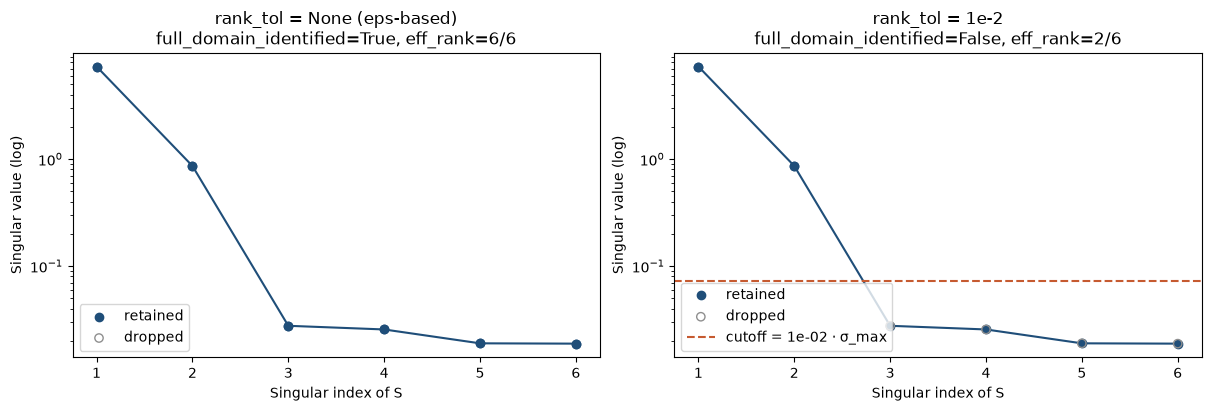

rank_tol=None -> J accessible: yes (would allow spectral claims)
rank_tol=1e-2 -> J accessible: correctly blocked


In [10]:
def collinear_S_and_U(J, *, true_directions=2, n_guides=20, kd=0.7, noise_S=0.005, seed=3):
    rng = np.random.default_rng(seed)
    d = J.shape[0]
    basis = rng.normal(size=(d, true_directions))
    weights = rng.normal(size=(true_directions, n_guides))
    U = basis @ weights
    U /= np.linalg.norm(U, axis=0, keepdims=True)
    U *= kd
    S = -np.linalg.solve(J, U) + noise_S * rng.normal(size=(d, n_guides))
    return U, S


U_col, S_col = collinear_S_and_U(J_true)
lax = ao.measure_from_sensitivity(S_col, U_col, reg="tsvd", reg_param="path", rank_tol=None)
strict = ao.measure_from_sensitivity(S_col, U_col, reg="tsvd", reg_param="path", rank_tol=1e-2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0), constrained_layout=True)
for ax, m, label in zip(axes, [lax, strict], ["rank_tol = None (eps-based)", "rank_tol = 1e-2"]):
    r = m.report
    ranks = np.arange(1, r.singular_values.size + 1)
    ax.semilogy(ranks, r.singular_values, "o-", color="#1f4e79")
    kept = r.retained_singular_directions
    ax.scatter(ranks[kept], r.singular_values[kept], color="#1f4e79", zorder=3, label="retained")
    ax.scatter(ranks[~kept], r.singular_values[~kept], facecolors="none",
               edgecolors="#8f8f8f", zorder=3, label="dropped")
    if r.rank_tol is not None:
        cutoff = r.rank_tol * float(r.singular_values[0])
        ax.axhline(cutoff, ls="--", color="#c65a30", label=f"cutoff = {r.rank_tol:.0e} · σ_max")
    ax.set_xlabel("Singular index of S")
    ax.set_ylabel("Singular value (log)")
    ax.set_title(f"{label}\nfull_domain_identified={r.full_domain_identified}, "
                 f"eff_rank={r.effective_response_rank}/{r.d}")
    ax.legend(loc="lower left")
plt.show()

def try_j(m):
    try:
        _ = m.J
        return "yes (would allow spectral claims)"
    except ao.IdentifiabilityError:
        return "correctly blocked"

print("rank_tol=None -> J accessible:", try_j(lax))
print("rank_tol=1e-2 -> J accessible:", try_j(strict))

## Wrap-up

- The identified action `J P_X` matches the ground truth to noise floor.
- Complex-conjugate eigenvalue pairs and the one hyperbolic mode are recovered.
- The projected benchmark separates the four synthetic methods and both nulls.
- The preregistered symmetric/antisymmetric prediction is testable per method
  on the identified domain.
- The scientific `rank_tol=1e-2` refuses to hallucinate full rank when guides
  are effectively collinear.

Real Perturb-seq applications use the same `ao.compare` and `ao.linearity_check`
downstream of `ao.measure_operator`. The protocol notebooks (`01_measure_k562`,
`02_benchmark`, `03_archetypes`) are deliberately unexecuted until pinned
public data are supplied.